# Decision Tree Classifier

- Decision_Tree: splits data into branches based on feature values to reach a prediction
- Easy to visualize and interpret, but can overfit if too deep
- Dataset: Social_Network_Ads.csv (predicting Purchased)
           [https://www.kaggle.com/code/swahajraza/social-network-ads/input](https://)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Social_Network_Ads.csv')
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


## Model Building
problem statement -  The goal is to build a Decision Tree classifier that predicts whether a new user will purchase the product based on their Age and Estimated Salary.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

x = df.drop('Purchased', axis=1)
y = df['Purchased']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("actual values:")
print(y_test.values)
print("predicted values:")
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

actual values:
[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 1]
predicted values:
[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0
 1 0 1 1 0 0]
Accuracy: 0.8375
              precision    recall  f1-score   support

           0       0.87      0.88      0.88        52
           1       0.78      0.75      0.76        28

    accuracy                           0.84        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.84      0.84      0.84        80

[[46  6]
 [ 7 21]]


In [ ]:
importance = pd.DataFrame({'feature': x.columns, 'importance': model.feature_importances_})
importance = importance.sort_values('importance', ascending=False)
print(importance)

           feature  importance
1  EstimatedSalary    0.513045
0              Age    0.486955


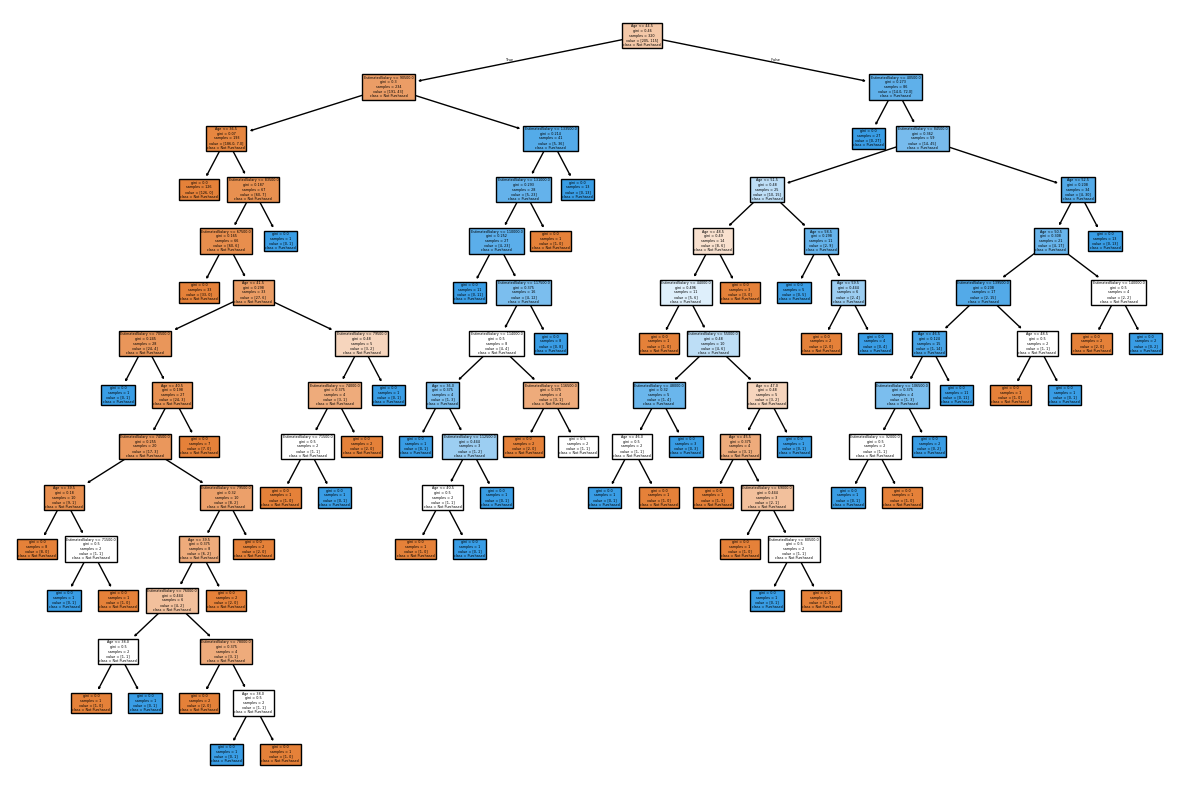

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=x.columns, class_names=['Not Purchased', 'Purchased'], filled=True)
plt.show()

## Conclusion
This notebook demonstrated a Decision Tree Classifier predicting product purchase with 83.75% accuracy using Age and EstimatedSalary. While effective, further improvements could include hyperparameter tuning or exploring other algorithms.
